# Interpretazione di una rete neurale per compliance normativa in ambito bancario

Banca Virtuosa, istituto di riferimento nel settore finanziario, ha identificato l'esigenza di migliorare la trasparenza e la comprensibilità dei modelli di intelligenza artificiale utilizzati nei propri sistemi. Per raggiungere questo obiettivo, Banca Virtuosa ha lanciato un progetto mirato all'implementazione di tecniche di Explainable AI (XAI), in conformità con la normativa vigente sulla trasparenza bancaria.

Attualmente, Banca Virtuosa utilizza modelli di classificazione pre-addestrati per analizzare e classificare dati finanziari critici. Tuttavia, la mancanza di trasparenza nelle decisioni di questi modelli può compromettere la fiducia dei clienti e limitare la capacità della banca di migliorare i propri sistemi in modo mirato. Identificare e correggere gli errori di classificazione è cruciale per garantire accuratezza e affidabilità nei servizi offerti.

## Benefici della Soluzione

**Trasparenza nelle Decisioni del Modello:** Implementando tecniche di XAI come Grad-CAM, LIME, SHAP, Integrated Gradients e Occlusion Maps, Banca Virtuosa sarà in grado di generare mappe di salienza che mostrano visivamente quali elementi influenzano le decisioni del modello. Questo incremento di trasparenza migliorerà la fiducia dei clienti e degli stakeholder, dimostrando l'affidabilità e la spiegabilità delle operazioni del sistema di classificazione.

**Miglioramento Continuo delle Performance:** Analizzando le mappe di salienza, Banca Virtuosa potrà identificare con precisione le aree in cui il modello commette errori, sia nelle classificazioni corrette che in quelle errate. Questa analisi dettagliata permetterà di apportare miglioramenti mirati al modello, ottimizzando le sue performance e riducendo il rischio di interpretazioni errate dei dati.

**Conformità Normativa:** Il progetto garantirà che le decisioni dei modelli di intelligenza artificiale siano spiegabili, in linea con i requisiti normativi vigenti. La trasparenza delle decisioni AI è essenziale per la conformità normativa e la governance aziendale, particolarmente in settori regolamentati come quello finanziario.

**Promozione dell'Innovazione:** L'utilizzo di tecniche avanzate di XAI all'interno di Banca Virtuosa promuoverà l'innovazione nel campo dell'intelligenza artificiale. Questo rafforzerà la posizione della banca come pioniere nell'adozione di tecnologie avanzate, consentendo di offrire ai clienti soluzioni sempre più sofisticate e affidabili.

## Dettagli del Progetto

**Fase 1: Utilizzo di un Modello di Classificazione Pre-Addestrato**
- Modello: Utilizzare un modello pre-addestrato, come DenseNet, dalla libreria torchvision.
- Dataset: Applicare il modello a un dataset di immagini, ad esempio MNIST, per esplorare le sue decisioni di classificazione.

**Fase 2: Generazione di Mappe di Salienza**
- Tecniche di XAI: Implementare tecniche come Grad-CAM, LIME, SHAP, Integrated Gradients e Occlusion Maps per generare mappe di salienza del modello.

**Fase 3: Report Finale**
- Descrizione del Dataset: Dettagliare l'origine, la struttura e le caratteristiche del dataset utilizzato.
- Analisi delle Mappe di Salienza: Confrontare le mappe di salienza per classi corrette ed errate per identificare e comprendere gli errori del modello.
- Sistema Spiegabile (Opzionale): Descrivere un sistema completamente spiegabile che potrebbe eseguire la stessa classificazione, offrendo ulteriori insights sulle decisioni del modello.

## Obiettivi del Progetto

- **Comprensione del Modello:** Utilizzare tecniche di XAI per ottenere una comprensione approfondita del funzionamento interno del modello pre-addestrato.
- **Visualizzazione delle Decisioni:** Visualizzare in modo chiaro e interpretabile quali elementi influenzano le decisioni del modello attraverso le mappe di salienza.
- **Identificazione degli Errori:** Analizzare le mappe di salienza per identificare e comprendere gli errori del modello, distinguendo tra classificazioni corrette ed errate.
- **Creazione di Sistemi Spiegabili:** Se possibile, sviluppare o descrivere un sistema completamente spiegabile che possa effettuare la stessa classificazione, fornendo ulteriori insights sulle decisioni del modello.

# Implementazione

Il progetto implementa un'analisi completa per BancaVirtuosa, al fine di migliorare la trasparenza, ottimizzare le performance dei modelli e garantire la conformità normativa. Con questo progetto, la banca mira a rafforzare la fiducia dei clienti, migliorare l'efficienza operativa e promuovere l'innovazione nel campo dell'intelligenza artificiale. Il notebook fornirà, oltre all'implementazione, il processo verso un sistema quanto più spiegabile possibile con analisi e reportistiche opportune.

## Gestione delle dipendenze

Cominciamo quindi con l'analisi delle dipendenze necessarie e il relativo import nel notebook:

In [1]:
#Standard library
import os
import sys
import time
import itertools

#Visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Numpy
import numpy as np

#PyTorch
import torch
import torchvision
from torchvision.models import densenet161, DenseNet161_Weights
from torchsummary import summary
import torch.nn as nn
import torch.nn.functional as F

#Scikit Learn
from sklearn.metrics import classification_report, confusion_matrix

#Albumentations
import albumentations as A
from albumentations.pytorch import ToTensorV2

#Captum for saliency maps
from captum.attr import Saliency, Occlusion

#RandomForest
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import IncrementalPCA

/home/azureuser/proai/course11-xai/project/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Importiamo inoltre il nostro modulo custom DNNHelper (https://github.com/crypto-infinity/dnnhelper):

In [2]:
# Importing our custom Helper 
!git clone https://github.com/crypto-infinity/dnnhelper
%cd dnnhelper

fatal: destination path 'dnnhelper' already exists and is not an empty directory.


/home/azureuser/proai/course11-xai/project/dnnhelper


In [3]:
from dnnhelper import Helper, Transforms, EarlyStopping, Experiment, CrossValidation, Trainer

In [4]:
%cd ..

/home/azureuser/proai/course11-xai/project


Definiamo, al termine del nostro setup, alcune costanti utili e alcune impostazioni del framework Deep Learning che useremo, PyTorch, come il device per il training dei modelli e il random seed per la riproducibilità:

In [5]:
#PyTorch DEVICE setup

DEVICE = Helper.set_device()
print(f"Using device: {DEVICE}")

Using device: cuda


In [6]:
#Random seed for reproducibility

SEED = 56

Helper.set_seed(SEED)
print(f"Random seed set to: {SEED}")

Random seed set to: 56


E costruiamo una prima pipeline per il loading delle immagini:

In [7]:
# Preprocessing default template

default_preprocessing_pipeline = A.Compose([
            A.Resize(256, 256),
            A.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
            ToTensorV2(),
        ])

iterations = [0,56,234,311]

## Discovery del dataset

Cominciamo ora ad importare il dataset che utilizzeremo, CIFAR10 (https://www.cs.toronto.edu/~kriz/cifar.html).

Dal sito del dataset sopra riportato, scopriamo che il dataset è composto di **10000 immagini di 3072 pixels** - *shape (3, 32, 32)* - con le relative labels (da 0 a 9).

Cominciamo perciò a codificarlo:

In [8]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck'] # 0 to 9, in order

n_classes = len(classes)

E conduciamone una prima esplorazione visiva, visualizzando alcuni dei sample del trainset:

In [9]:
trainset = torchvision.datasets.CIFAR10(root='./dataset', train=True,
                                        download=True, 
                                        transform=Transforms(default_preprocessing_pipeline))
train_dl = torch.utils.data.DataLoader(trainset, batch_size=32,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./dataset', train=False,
                                       download=True, 
                                       transform=Transforms(default_preprocessing_pipeline))
test_dl = torch.utils.data.DataLoader(testset, batch_size=32,
                                         shuffle=False, num_workers=2)

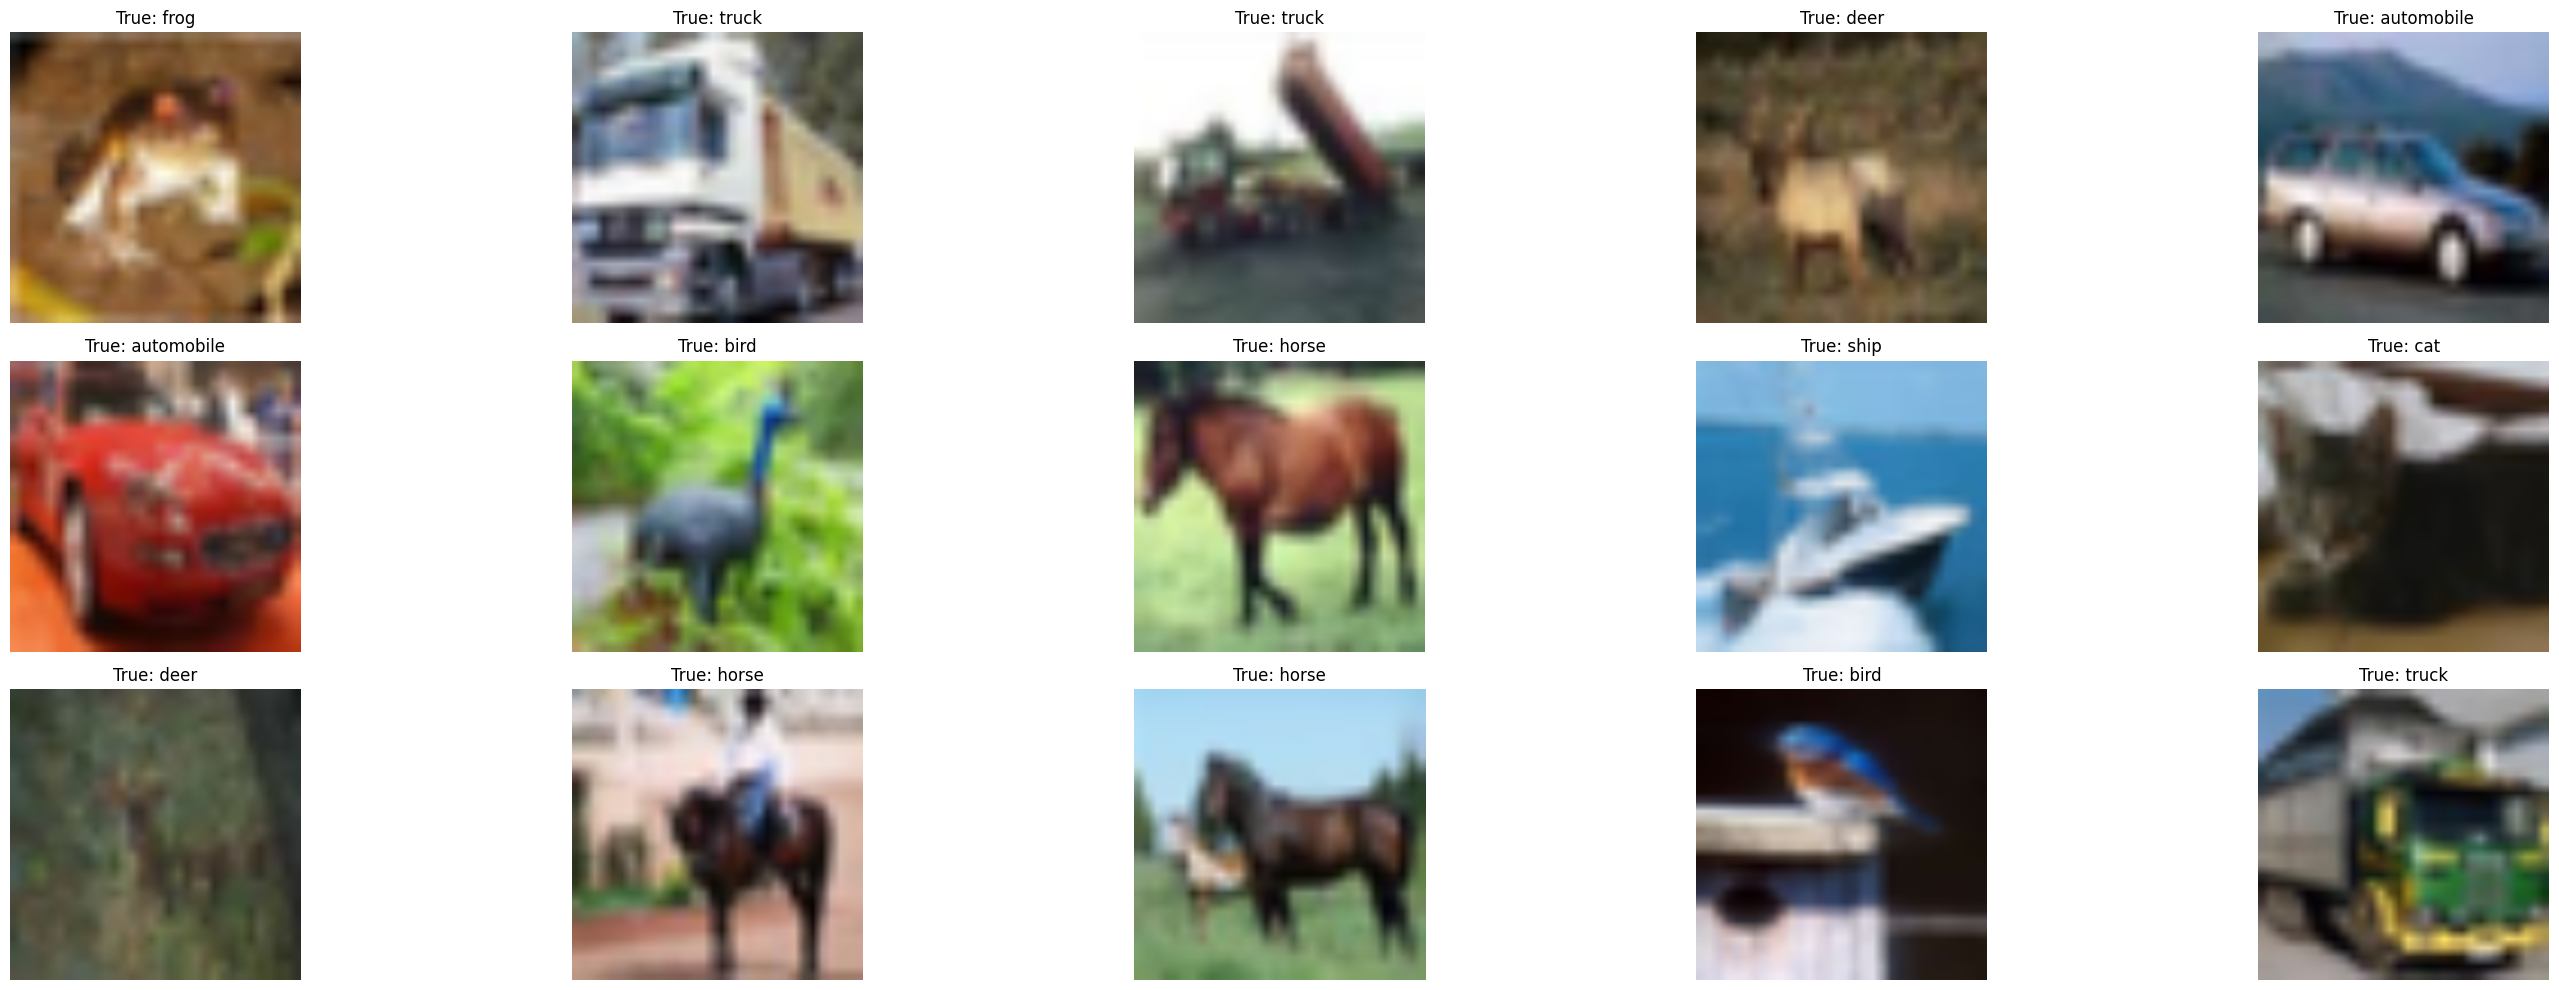

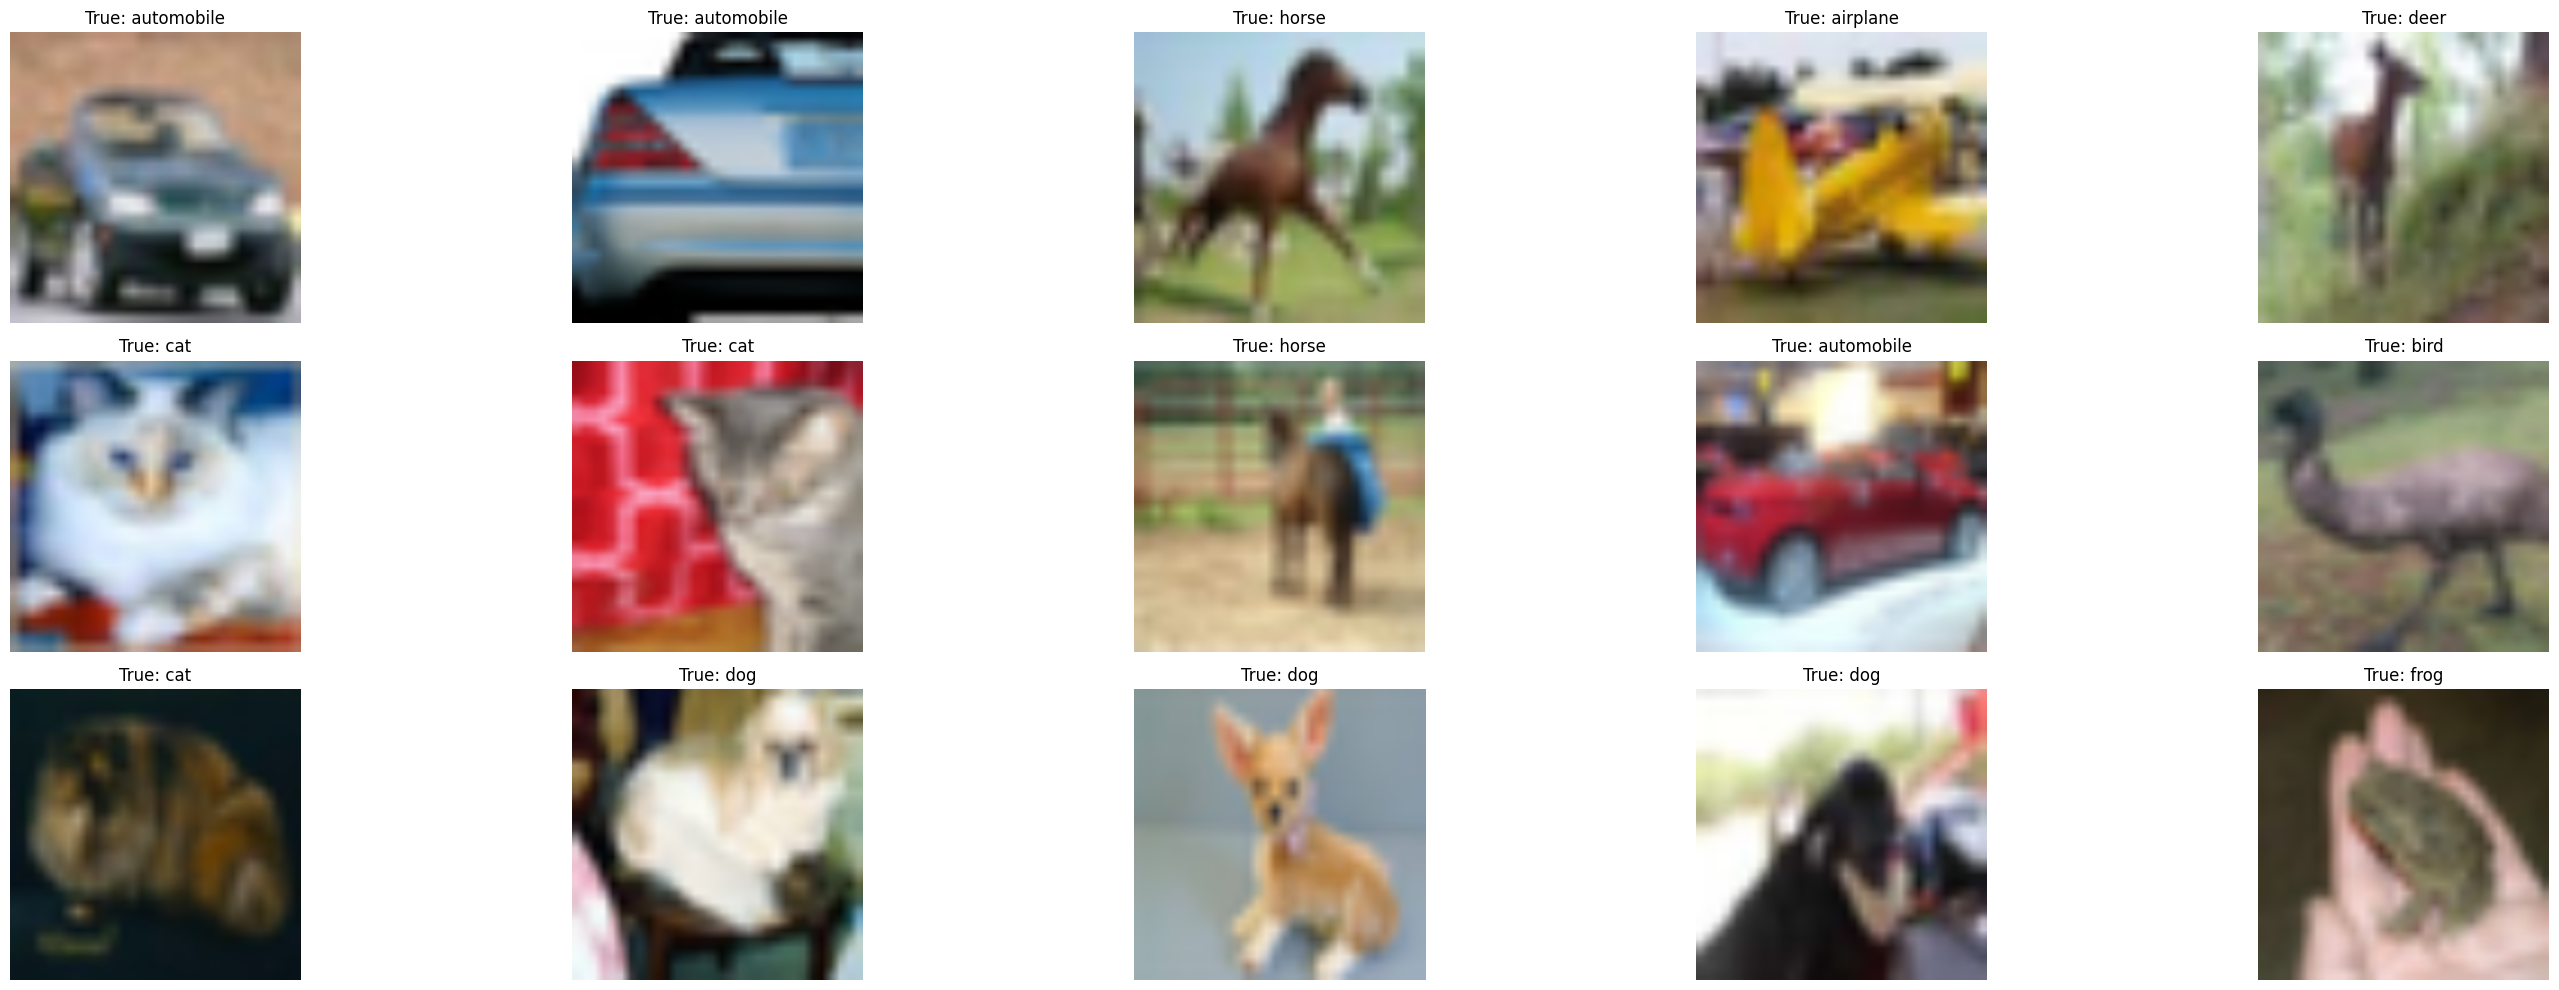

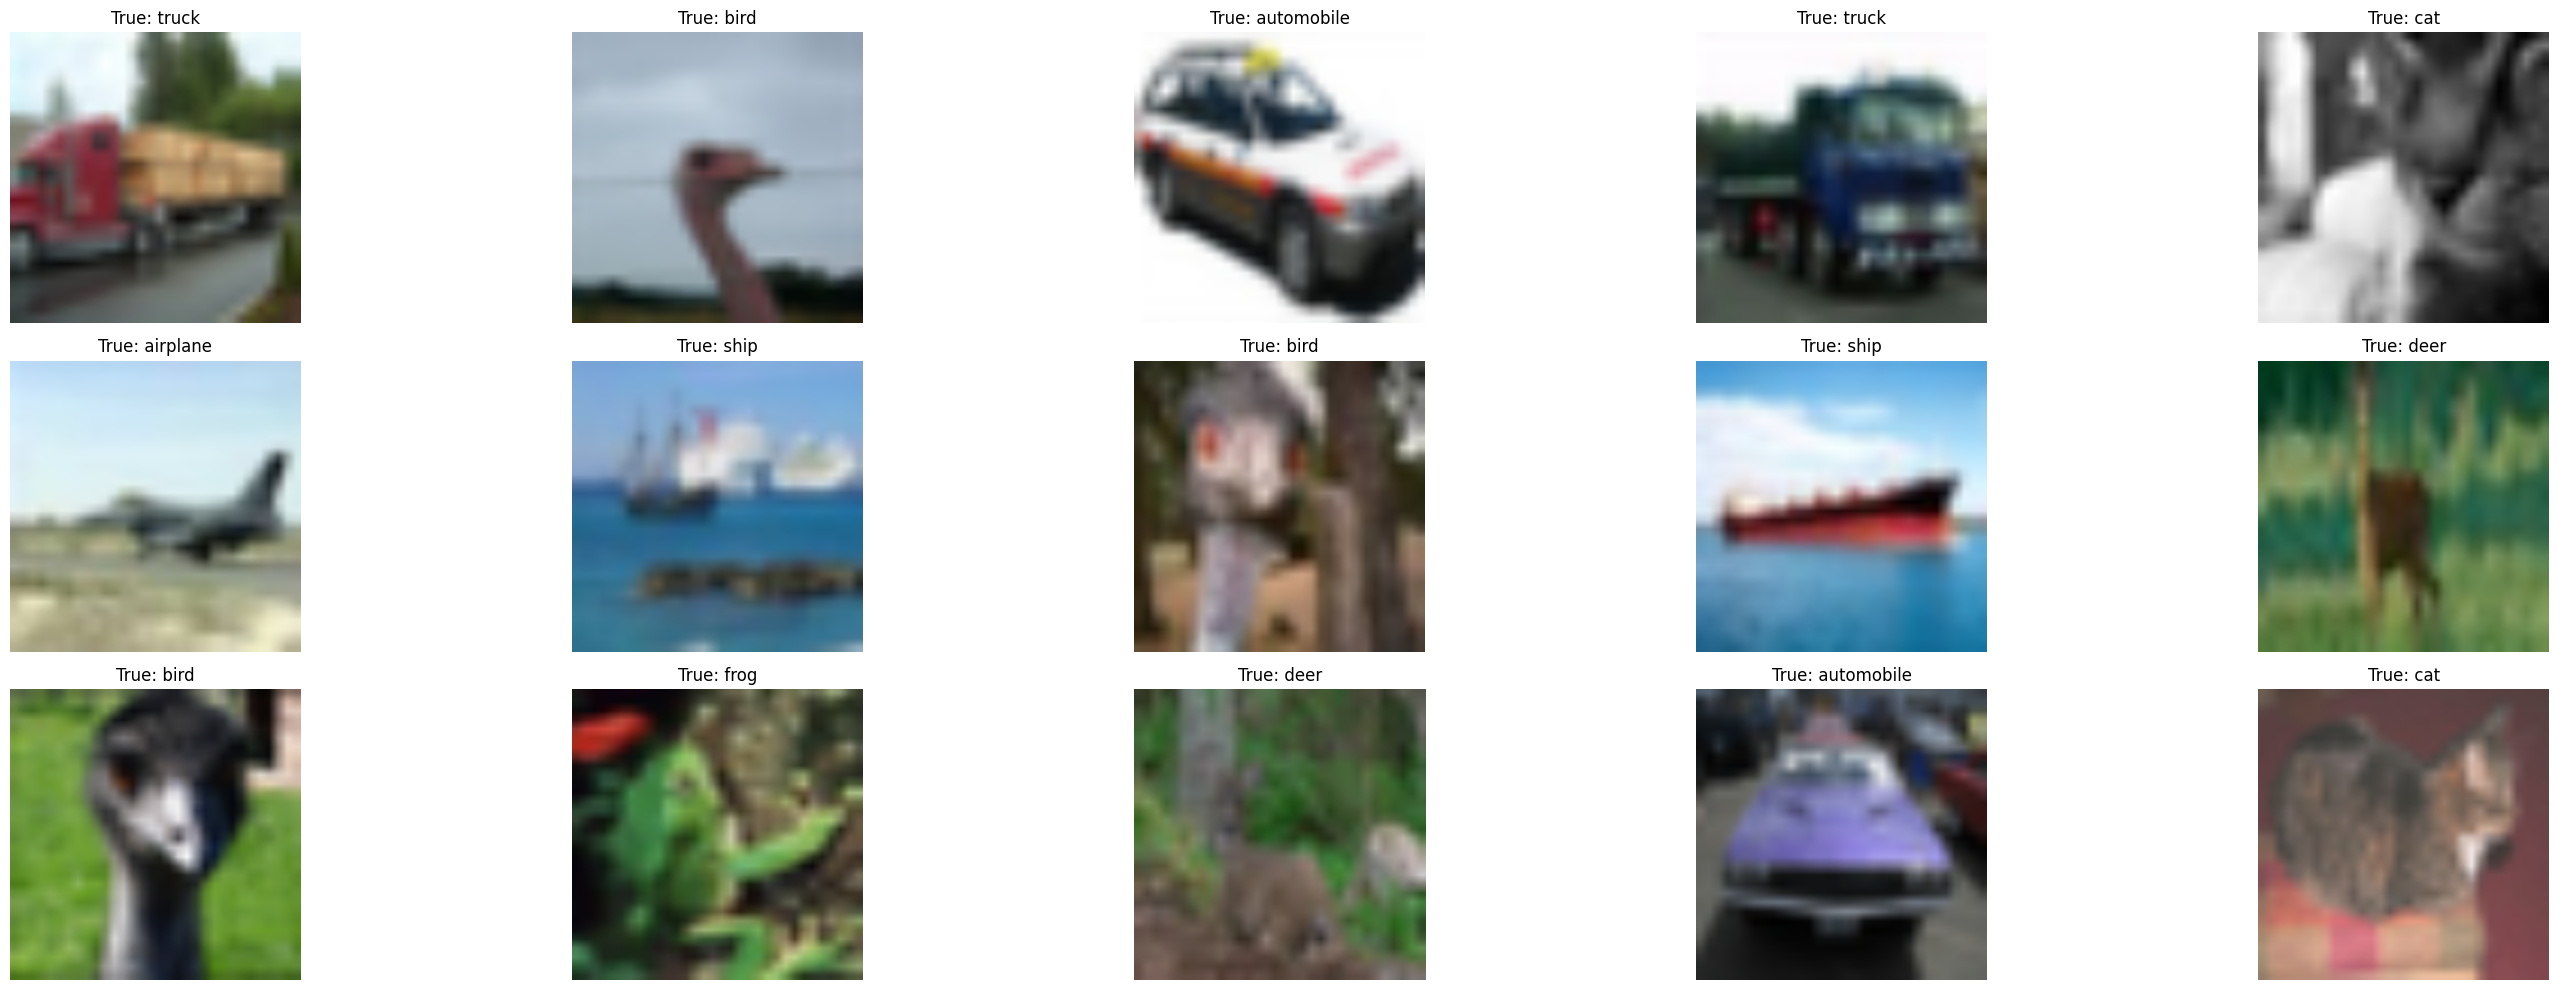

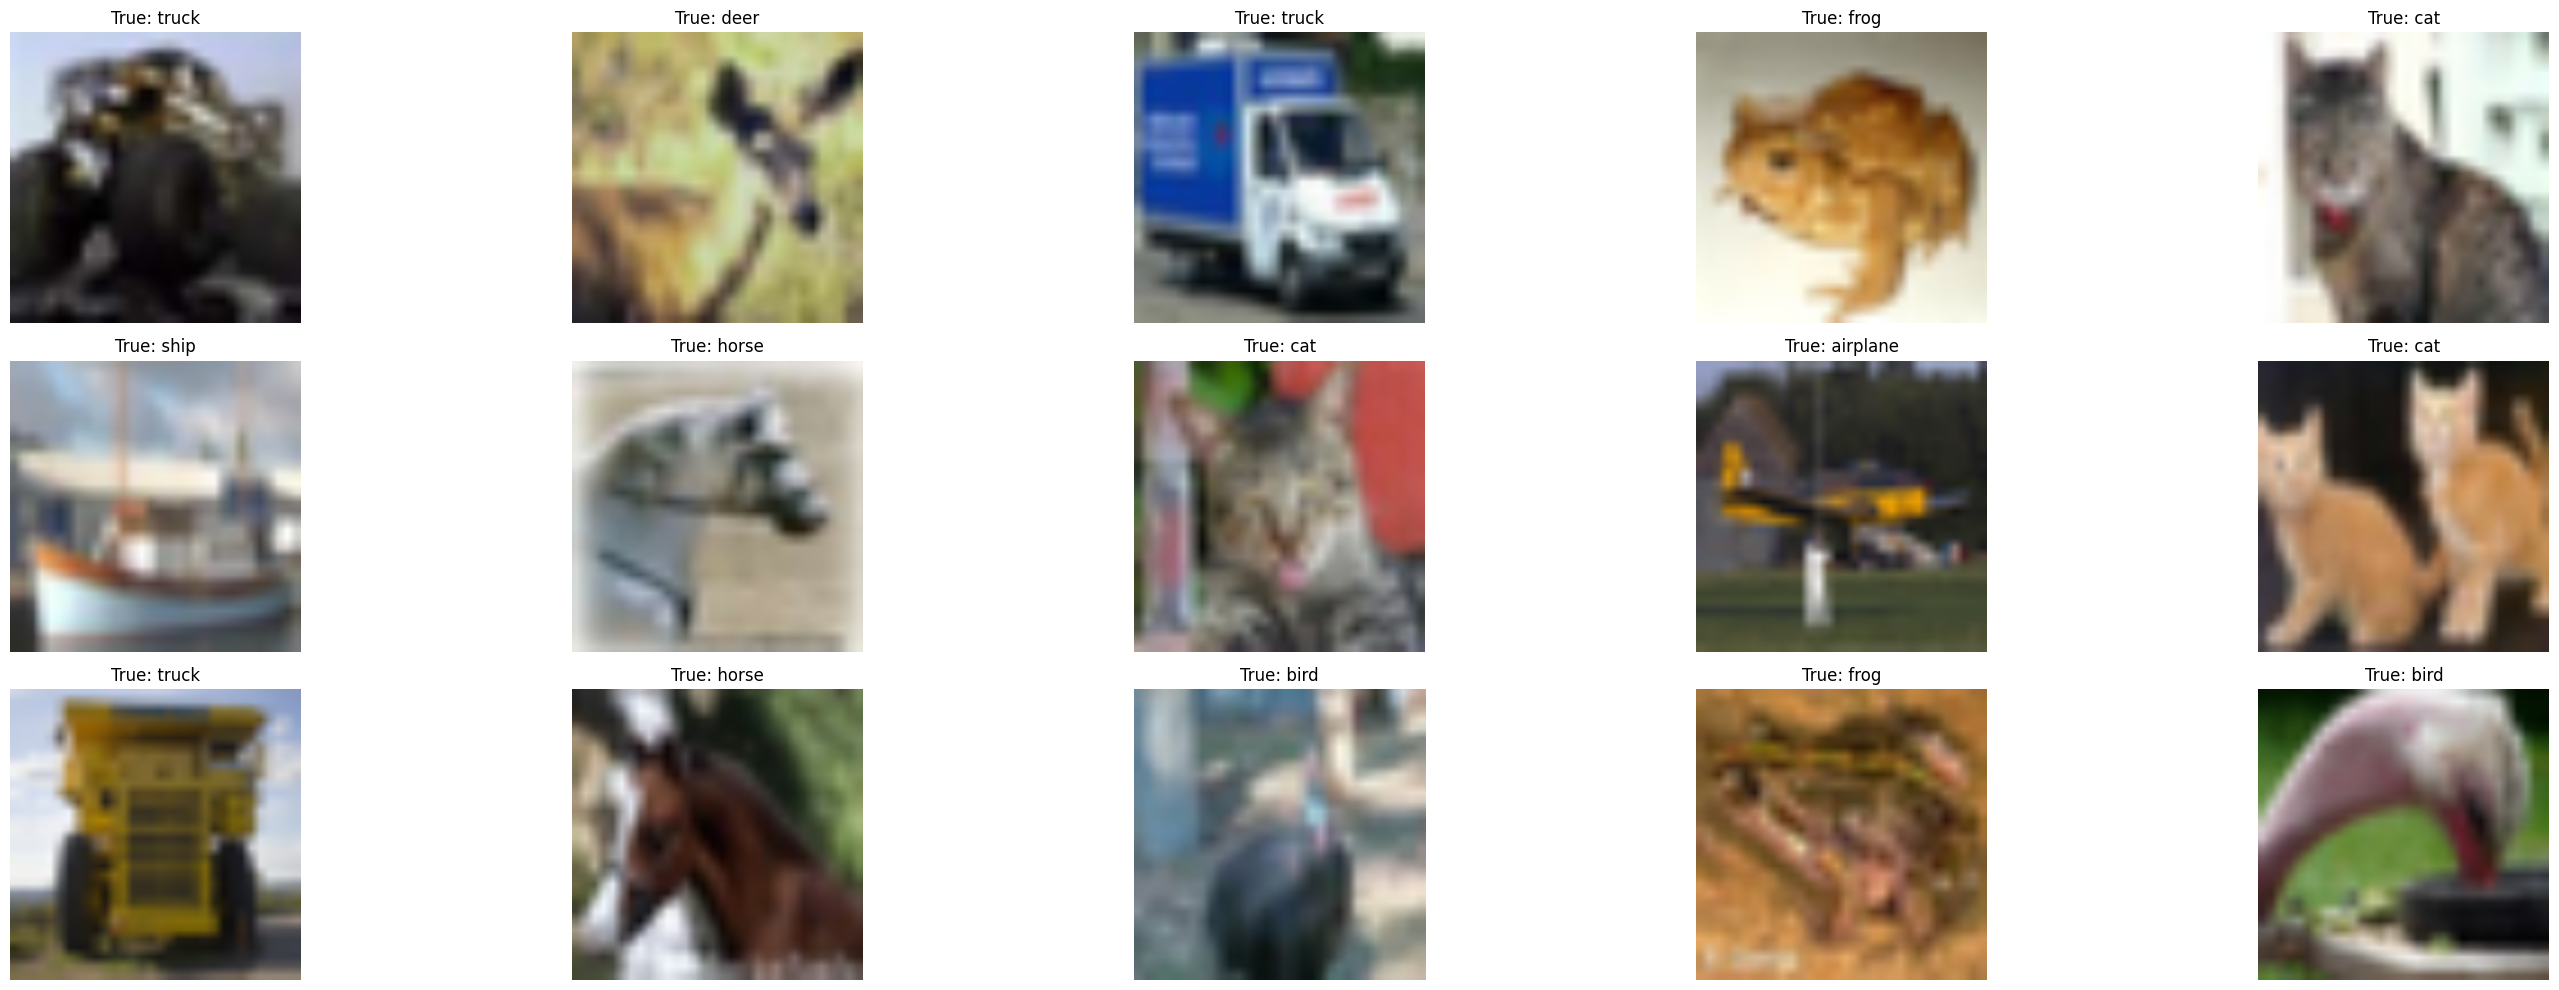

In [10]:
#First data exploration

trainset_defaultaug = trainset
trainset_defaultaug.transform = Transforms(default_preprocessing_pipeline)

for i in iterations:
    Helper.plot_images(trainset_defaultaug, trainset.classes, i)

del trainset_defaultaug

Concludiamo la prima discovery con la verifica delle distribuzioni delle classi:

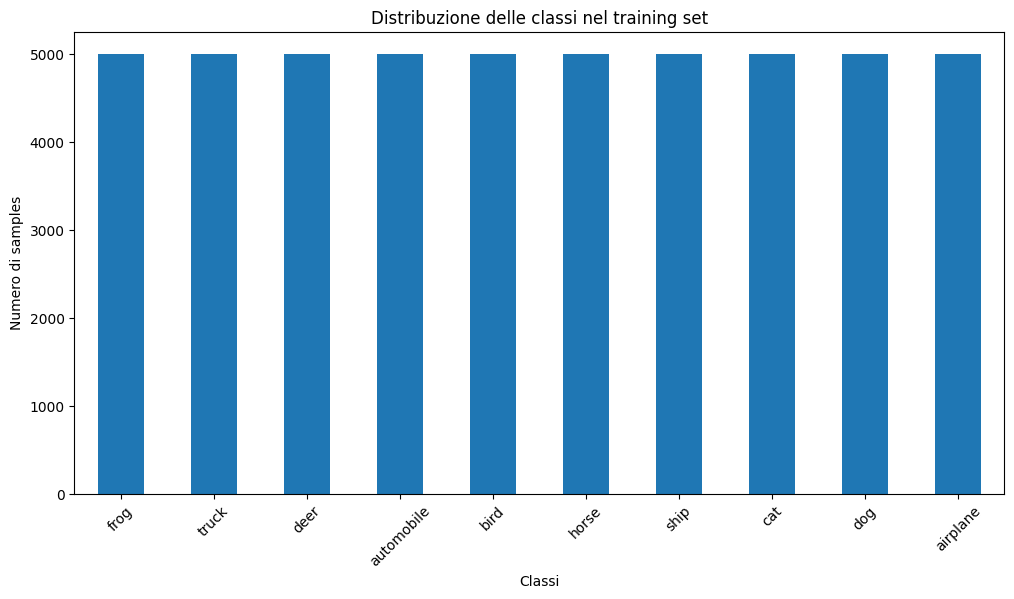

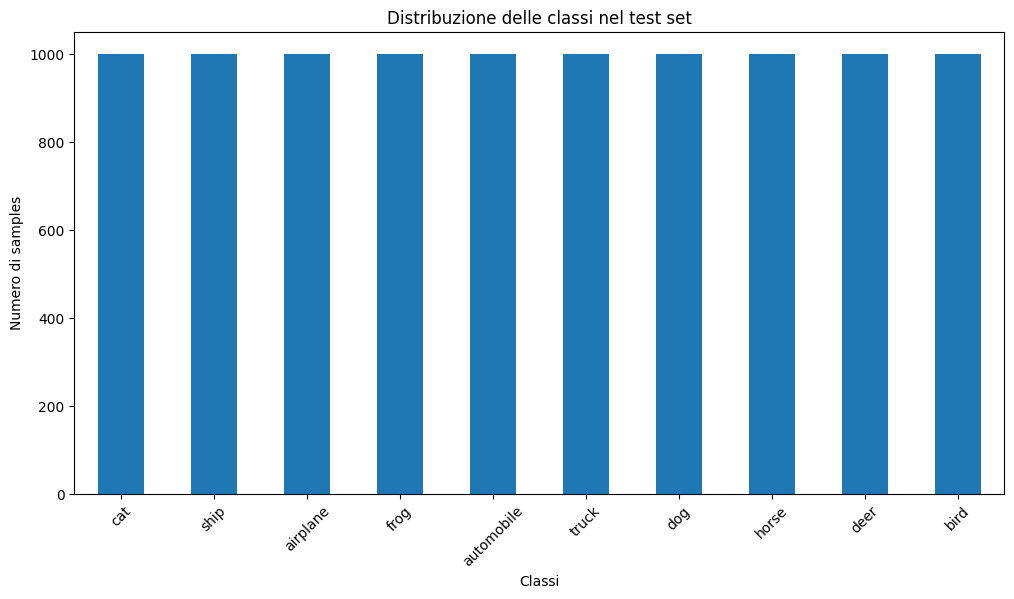

In [11]:
Helper.plot_class_distribution(trainset, type="training")
Helper.plot_class_distribution(testset, type="test")

In seguito, attraverso l'addestramento di una DenseNet come baseline, analizzeremo i campioni più confusi e le variabilità (con confusion matrix e mappe di salienza).

## Definizione della baseline di classificazione

Definiamo ora la rete DenseNet161 (https://docs.pytorch.org/vision/main/models/generated/torchvision.models.densenet161.html), come richiesto dal progetto, per effettuare alcune prime classificazioni del nostro dataset, analizzandone le metriche, le confusioni e le salienze dei vari pixels. Consideriamo CIFAR10 come un sottoproblema di ImageNet, perciò utilizzeremo gli stessi pesi.

In [12]:
# Import DenseNet with ImageNet weights
densenet = densenet161(weights=DenseNet161_Weights.IMAGENET1K_V1).to(DEVICE)

# Freeze all layers
for param in densenet.parameters():
    param.requires_grad = False

E costruiamo il nostro classificatore custom, che useremo per esplorare le decisioni di classificazione:

In [13]:
# Classifier with regularization

class RegolarizedClassifier(nn.Module):
    """
    Regularized (in the classifier part) convolutional classifier using DenseNet as backbone.
    """

    def __init__(self, densenet_backbone, in_features, n_classes):
        super().__init__()

        #backbone
        self.features = nn.Sequential(*list(densenet_backbone.children())[:-1])

        #fine-tuning
        self.pooling = nn.AdaptiveAvgPool2d((1,1))

        #Regularization
        self.dropout = nn.Dropout(p=0.2) #low dropout rate, an higher one would be too aggressive
        self.norm = nn.BatchNorm1d(in_features)

        #linear
        self.fc1 = nn.Linear(in_features, 2208)
        self.fc2 = nn.Linear(2208, n_classes)

    def forward(self, x):

        #backbone
        x = self.features(x) #[N, 2208, 8, 8]
        x = self.pooling(x) #[N, 2208, 1, 1]
        x = torch.flatten(x, 1) #[N, 2208]

        #dense
        x = F.relu(self.norm(self.fc1(x))) #normalizes the activations inputs
        x = self.dropout(x)
        x = self.fc2(x) #[N, 10]

        return x

In [14]:
regolarized = RegolarizedClassifier(densenet, 2208, n_classes).to(DEVICE)

In [15]:
print(regolarized)

RegolarizedClassifier(
  (features): Sequential(
    (0): Sequential(
      (conv0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (norm0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu0): ReLU(inplace=True)
      (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (denseblock1): _DenseBlock(
        (denselayer1): _DenseLayer(
          (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu1): ReLU(inplace=True)
          (conv1): Conv2d(96, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (norm2): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu2): ReLU(inplace=True)
          (conv2): Conv2d(192, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        )
        (denselayer2): _DenseLayer(
          (norm1): BatchNorm2d(144, eps=1e-05, m

Definiamo la nostra istanza con alcuni parametri di base per cominciare l'addestramento:

In [16]:
# Baseline hyperparameters

exp1 = Experiment(
    name = "autolr_regolarized",
    checkpoints_folder = 'models',
    checkpoint_name = "classifier.pt",
    model = regolarized,
    n_classes=n_classes,
    lr = 1e-4,
    lr_scheduler=True,
    lr_step=5,
    metrics = ["accuracy", "precision", "recall"],
    use_early_stopping = True,
    loss_fn = nn.CrossEntropyLoss,
    optimizer = torch.optim.Adam,
    epochs = 20,
    patience= 7,
    color = "#EB4310",
    alpha = .3,
)


E addestriamo la baseline:

In [17]:
# Train the model

start = time.time()

if not os.path.exists(f"./models/early_stoppings/{exp1.name}/{exp1.checkpoint_name}"):
    Trainer.fit(exp1, train_dl, test_dl, verbose=True)
else:
    exp1.model.load_state_dict(torch.load(f"./models/early_stoppings/{exp1.name}/{exp1.checkpoint_name}", map_location=DEVICE))

print(f"Tempo impiegato: {time.time() - start:.2f} minuti")

Tempo impiegato: 0.12 minuti


## Esplorazione delle decisioni di classificazione

Ora che la baseline è addestrata, procediamo ad utilizzare le tecniche XAI opportune (essendo i samples del dataset immagini, utilizzeremo **GradCAM e TracInCP**, come confronto, per generare le mappe di salienza richieste dal progetto.)

Cominciamo innanzitutto con un report dei risultati dell'addestramento:

Classification report for autolr_regolarized:



              precision    recall  f1-score   support

       plane       0.88      0.90      0.89      1000
         car       0.93      0.92      0.93      1000
        bird       0.89      0.86      0.88      1000
         cat       0.79      0.81      0.80      1000
        deer       0.89      0.87      0.88      1000
         dog       0.86      0.85      0.85      1000
        frog       0.90      0.94      0.92      1000
       horse       0.92      0.91      0.91      1000
        ship       0.91      0.93      0.92      1000
       truck       0.92      0.91      0.92      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



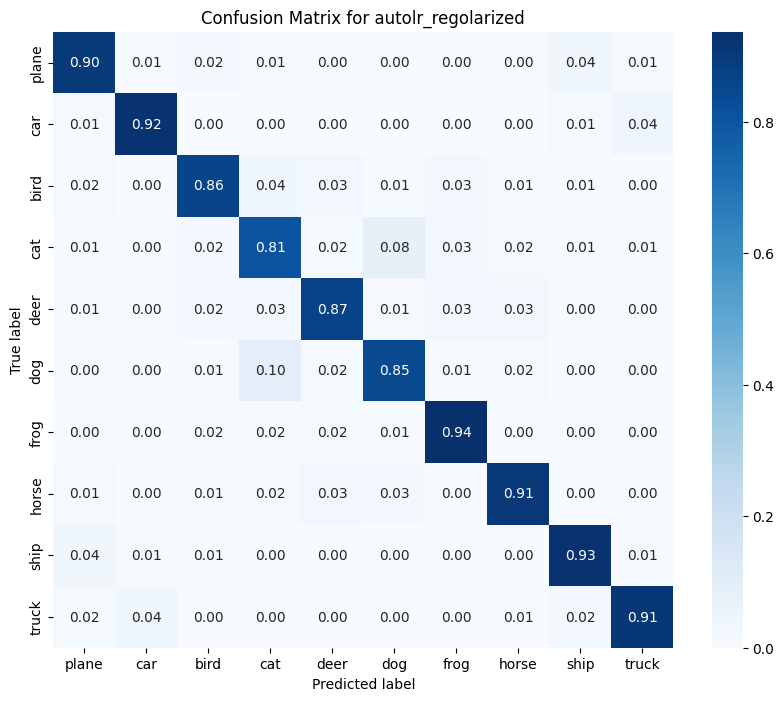

In [18]:
# Test set evaluation

y_pred = Helper.evaluate_experiment(exp1, testset, classes=classes, iterations=iterations)

## Mappe di salienza

Dopo un primo report di valutazione della classificazione, cerchiamo di comprendere l'importanza delle features che il modello ha attribuito loro durante il processo di classificazione. Utilizzeremo due tecniche, l'occlusion e la saliency.

Estraiamo quindi gli indici delle prime 3 predizioni corrette e delle 3 predizioni scorrette:

In [19]:
y_pred = np.array(Trainer.predict(exp1, test_dl))
y_true = np.array(testset.targets)

In [20]:
wrongly_classified_indexes = np.where(y_pred != y_true)[0][:3]
correct_classified_indexes = np.where(y_pred == y_true)[0][:3]

Ed estraiamo le immagini/labels in formato PyTorch, per essere consumate dalle classi di Salienza/Occlusion:

In [21]:
test_images, test_labels = [], []
for batch_imgs, batch_lbls in test_dl:
    test_images.extend(batch_imgs)
    test_labels.extend(batch_lbls)
test_images = torch.stack(test_images)
test_labels = torch.tensor(test_labels)

Mostriamo le rispettive immagini con entrambe le etichette, e le relative mappe sovrapposte.

**Immagini misclassificate:**

In [22]:
# Computing occlusion and saliency for misclassified classes

COMPUTE_SALIENCY = False

if COMPUTE_SALIENCY:
    fig, ax = plt.subplots(3, 3, figsize=(10, 6))

    for col, index in enumerate(wrongly_classified_indexes):
        # Original image
        img = test_images[index]
        label = test_labels[index]
        ax[0, col].imshow(Helper.back_to_image(img))
        title = f"True: {classes[label]} | Pred: {classes[y_pred[index]]}"
        ax[0, col].set_title(title, color="red")
        ax[0, col].axis("off")

        # Saliency map
        saliency = Saliency(regolarized)
        input_tensor = img.unsqueeze(0).to(DEVICE)
        input_tensor.requires_grad_()  #Avoid warnings
        saliency_attr = saliency.attribute(input_tensor, target=label.item())
        saliency_map = saliency_attr.abs().squeeze().sum(dim=0)
        saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min())
        ax[1, col].imshow(Helper.back_to_image(img))
        ax[1, col].imshow(saliency_map.cpu().numpy(), cmap='hot', alpha=0.50)
        ax[1, col].set_title('Saliency Map')
        ax[1, col].axis("off")

        # Occlusion map
        occlusion = Occlusion(regolarized)
        occlusion_attr = occlusion.attribute(
            input_tensor,
            target=label.item(),
            strides=(3, 2, 2),
            sliding_window_shapes=(3, 4, 4),
            baselines=0
        )
        occlusion_map = occlusion_attr.abs().squeeze().sum(dim=0)
        occlusion_map = (occlusion_map - occlusion_map.min()) / (occlusion_map.max() - occlusion_map.min())
        ax[2, col].imshow(Helper.back_to_image(img))
        ax[2, col].imshow(occlusion_map.cpu().numpy(), cmap='hot', alpha=0.50)
        ax[2, col].set_title('Occlusion Map')
        ax[2, col].axis("off")

    plt.tight_layout()
    plt.show()

Notiamo a quali aree la CNN dà più importanza (e la comprensibile confusione derivante) in particolare sul caso del cerbiatto, dove la CNN valuta feature più simili a quelle della classe erroneamente predetta, il cavallo.

Caso simile per il cane, in realtà completamente confuso con un gatto.

Sembra quindi che la rete abbia difficoltà a distinguere elementi molto simili e casi di sovrapposizioni di features.

**Immagini correttamente classificate:**

In [23]:
# Computing occlusion and saliency for correctly classified classes

if COMPUTE_SALIENCY:
    fig, ax = plt.subplots(3, 3, figsize=(10, 6))

    for col, index in enumerate(correct_classified_indexes):
        # Original image
        img = test_images[index]
        label = test_labels[index]
        ax[0, col].imshow(Helper.back_to_image(img))
        title = f"True: {classes[label]} | Pred: {classes[y_pred[index]]}"
        ax[0, col].set_title(title)
        ax[0, col].axis("off")

        # Saliency map
        saliency = Saliency(regolarized)
        input_tensor = img.unsqueeze(0).to(DEVICE)
        input_tensor.requires_grad_()  #Avoid warnings
        saliency_attr = saliency.attribute(input_tensor, target=int(label.item()))
        saliency_map = saliency_attr.abs().squeeze().sum(dim=0)
        saliency_map = (saliency_map - saliency_map.min()) / (saliency_map.max() - saliency_map.min())
        ax[1, col].imshow(Helper.back_to_image(img))
        ax[1, col].imshow(saliency_map.cpu().numpy(), cmap='hot', alpha=0.50)
        ax[1, col].set_title('Saliency Map')
        ax[1, col].axis("off")

        # Occlusion map
        occlusion = Occlusion(regolarized)
        occlusion_attr = occlusion.attribute(
            input_tensor,
            target=int(label.item()),
            strides=(3, 2, 2),
            sliding_window_shapes=(3, 4, 4),
            baselines=0
        )
        occlusion_map = occlusion_attr.abs().squeeze().sum(dim=0)
        occlusion_map = (occlusion_map - occlusion_map.min()) / (occlusion_map.max() - occlusion_map.min())
        ax[2, col].imshow(Helper.back_to_image(img))
        ax[2, col].imshow(occlusion_map.cpu().numpy(), cmap='hot', alpha=0.50)
        ax[2, col].set_title('Occlusion Map')
        ax[2, col].axis("off")

    plt.tight_layout()
    plt.show()

Notiamo comunque che il modello, nonostante le sovrapposizioni e le similarità (probabilmente endemiche del dataset), risulta piuttosto solido nell'identificare le features più appropriate per la classe corrispondente. Nel caso delle navi focalizza correttamente l'attenzione sulla base, nel caso del gatto sulla forma del corpo dell'animale.

Nel complesso, considerando anche le metriche, il modello performa in maniera discreta, e a nostro avviso può essere reputato solido nelle decisioni (non scambia insomma la nave per il cielo, nonostante il cielo abbia comunque rilevanza).

## Sistema spiegabile

Effettuiamo anche un tentativo generando un sistema white-box, sfruttando un **RandomForestClassifier** addestrato sfruttando le funzionalità di feature extraction della rete DenseNet. L'albero di decisione ci consentirà di avere maggiore visibilità sulle scelte del modello.

Cominciamo ad estrarre le features dalle immagini attraverso la backbone DenseNet, da usare come input per il Classifier:

In [24]:
# Feature extractor with DenseNet

class DenseNetFeatureExtractor(nn.Module):
    """
    Feature Extractor based on the convolutional part of DenseNet.
    """

    def __init__(self, densenet_backbone):
        super().__init__()

        #backbone
        self.features = densenet_backbone.features

        #pooling
        self.pooling = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):

        #backbone
        x = self.features(x) #[N, 2208, 8, 8]
        x = self.pooling(x) #[N, 2208, 1, 1]
        x = torch.flatten(x, 1) #[N, 2208]

        return x

In [25]:
feature_extractor = DenseNetFeatureExtractor(densenet)
feature_extractor

DenseNetFeatureExtractor(
  (features): Sequential(
    (conv0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (norm0): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu0): ReLU(inplace=True)
    (pool0): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (denseblock1): _DenseBlock(
      (denselayer1): _DenseLayer(
        (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu1): ReLU(inplace=True)
        (conv1): Conv2d(96, 192, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (norm2): BatchNorm2d(192, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu2): ReLU(inplace=True)
        (conv2): Conv2d(192, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
      (denselayer2): _DenseLayer(
        (norm1): BatchNorm2d(144, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tr

In [26]:
feature_extractor.eval()
features = []

for _, data in enumerate(train_dl, 0):
    X = data[0].to(DEVICE)
    with torch.no_grad():
        features.append(feature_extractor(X).cpu().numpy())

features = np.concatenate(features, axis=0)

In [35]:
feature_extractor.eval()
test_features = []

for _, data in enumerate(train_dl, 0):
    X = data[0].to(DEVICE)
    with torch.no_grad():
        test_features.append(feature_extractor(X).cpu().numpy())

test_features2 = np.concatenate(test_features, axis=0)

E ora concentriamoci all'applicazione del RandomForestRegressor. Alcuni esperimenti hanno mostrato che il modello non performa bene con 2208 features, come anche altri modelli più semplici. Applichiamo quindi la PCA (incrementale, data la dimensione del dataset) per ridurre la dimensionalità a 200 features, selezionando le più informative:

In [ ]:
pca = IncrementalPCA(n_components=200)
features_pca = pca.fit_transform(features)
test_features_pca = pca.transform(test_features)

E procediamo all'addestramento del RandomForestClassifier:

In [29]:
rfc = RandomForestClassifier(
    n_estimators=400,
    max_depth=30,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=2,
    random_state=SEED
)